# A tour of the STARfinder shared foundation

This notebook introduces the design of the maintained Python package by running it
on one small synthetic scene. It covers the package layout and array conventions,
the formed-amplicon synthetic generator and its explicit truth, one field of view
(FOV) through the typed pipeline API with checkpoints, the checkpoint layout and
run record, a comparison of decoded molecules with the synthetic truth, and how
development is checked.

Every section explains a design choice first and then runs the code that shows it.
The design itself is documented in `docs/`; this notebook links those pages rather
than repeating them.

**Scope and resources.** The notebook generates one FOV of the `small` benchmark
preset (16×256×256 voxels, four rounds, four channels) in memory. It needs no
downloaded data, MATLAB, GPU or network access. Every random draw comes from the
preset's fixed seed, so a second execution prints the same numbers on the same
host and NumPy build. Files are written only under a temporary directory that the
notebook creates and removes in its last cell. On one CPU thread a full execution
took about ten seconds and about 0.3 GiB of memory on the development host;
both depend on the host.

To execute it from `src/python` in a locked environment that includes the `dev`
group (which provides Jupyter):

```bash
uv run jupyter nbconvert --to notebook --execute --output-dir <new directory> \
    ../../example/introduction/starfinder_foundation_tour.ipynb
```

The setup cell draws figures inline, keeps numerical libraries on one thread
(set before NumPy is imported, so the run is bounded and repeatable) and creates
the temporary workspace. The helper `rel` prints paths relative to that workspace, so no
machine-specific path appears in the output.

In [1]:
%matplotlib inline
import os

for variable in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(variable, "1")

import json
import tempfile
from dataclasses import replace
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

_workspace = tempfile.TemporaryDirectory(prefix="starfinder-tour-")
WORKSPACE = Path(_workspace.name)


def rel(path):
    # Show a path relative to the temporary workspace.
    return Path(path).relative_to(WORKSPACE).as_posix()


print("workspace: a new temporary directory; it is removed at the end")
print("files in it:", sorted(WORKSPACE.iterdir()))

workspace: a new temporary directory; it is removed at the end
files in it: []


## 1. Architecture and conventions

STARfinder separates **numerical functions** from **workflow state**. Each
subpackage owns one kind of work and returns typed results; the dataset layer
coordinates those functions for one FOV but does not reimplement them. Batch and
streaming execution change which images stay in memory, not the scientific
pipeline. The ownership table and its boundaries are in
[docs/architecture.md](../../docs/architecture.md). In short:

* `image`: `ImageMetadata` and spatial validation; `io`: TIFF and table persistence.
* `preprocessing`, `registration`, `spot_finding`: typed image operations,
  transform estimation and application, and detection with stable spot identities.
* `barcode`: codebook validation, intensity extraction, decoding and read filtering.
* `dataset`: `Dataset`/`FOV` coordination, the typed `PipelineConfig`, execution
  policy and checkpoints.
* `synthetic`: formed-amplicon scenes and their truth; `evaluation`: pure metrics on
  supplied data; `benchmark`: cases, timing, manifests and reports.

The conventions that cross these boundaries are set out in
[docs/conventions.md](../../docs/conventions.md). The main ones used below:

* Images are NumPy arrays in **ZYX** (one channel) or **ZYXC** order, with spatial
  metadata kept separately in `ImageMetadata`. Spot tables use named `z, y, x`
  columns with 0-based voxel indices.
* **Channel order is explicit.** The loader uses exactly the channel list it is
  given and never infers wavelength order. This synthetic data uses
  `ch00, ch01, ch02, ch03`; the real-data MATLAB default is `ch00, ch02, ch01, ch03`.
* Configuration objects are **frozen, validated dataclasses** that reject bad
  values before any image is touched. Results are **typed dataclasses** that keep
  identities, labeled axes and diagnostics, instead of loose dictionaries.

The next cell reads each subpackage's own summary from its docstring, then shows
validation happening when a configuration is built.

In [2]:
import importlib

for name in ("image", "io", "preprocessing", "registration", "spot_finding", "barcode",
             "dataset", "synthetic", "evaluation", "benchmark"):
    module = importlib.import_module(f"starfinder.{name}")
    print(f"{name:<14} {module.__doc__.strip().splitlines()[0]}")

image          Image geometry and finite ZYX/ZYXC array contracts.
io             Image persistence and explicit intensity conversion.
preprocessing  Finite ZYX/ZYXC image operations and their typed configuration.
registration   Typed transform estimation and application in voxel-index coordinates.
spot_finding   Explicit pipeline and registration landmark detection policies.
barcode        Validated codebooks and independent intensity extraction, decoding and filtering.
dataset        Dataset/FOV coordination and validated processing/execution policies.
synthetic      Formed-scene synthetic generation: oracle fixtures and benchmark datasets.
evaluation     Pure domain metrics: supplied data in, structured results out.
benchmark      Explicit benchmark cases, trial records and saved-artifact lifecycle.


In [3]:
from starfinder.dataset import CheckpointConfig
from starfinder.spot_finding import LocalMaximaConfig

print(LocalMaximaConfig(threshold_mode="noise", threshold_value=5.0, min_distance_voxels=1))
try:
    CheckpointConfig(table_format="xlsx")
except ValueError as error:
    print("rejected at construction:", error)

LocalMaximaConfig(threshold_mode='noise', threshold_value=5.0, min_distance_voxels=1, exclude_border=True, channel_labels=None, measure_peak_intensity=True, method='local_maxima')
rejected at construction: table_format must be csv or parquet


## 2. Synthetic formed-amplicon scenes

The synthetic model starts **after amplicon formation**: each amplicon has a fixed
identity, gene, codeword and reference position, and every sequencing round is a
new *readout* of that same population. Per-round effects (signal trend, channel
crosstalk, dropout, loss), motion, background and noise are separate, ordered
stages that are all disabled by default and must be switched on explicitly. The
truth is therefore explicit rather than inferred: the formed amplicon table, the
per-round positions and flags, and the float64 signal tensors `intended`,
`pre_mix` and `realized` (amplicon × channel × round). The model and its effect
order are specified in
[docs/synthetic-specification.md](../../docs/synthetic-specification.md).

**Presets.** One registry, `SCENE_PRESETS`, holds three tiers: literal test
fixtures, oracle-checked development fixtures and the benchmark presets. A
benchmark preset keeps the historical size, amplicon count, seed and shift range,
and adds documented appearance defaults (`benchmark-presets-v1`). Those defaults
are engineering choices, not calibrated against acquired images.

**Independent random streams.** Every random draw has its own generator, keyed
by a JSON array (namespace, split, seed, scene key, component, entity, round,
channel) that is hashed with SHA-256 to seed a NumPy `PCG64` generator. Changing
one component, such as noise, therefore never changes another component's draws,
and no result depends on global random state or `PYTHONHASHSEED`.

The cell below reads the registry entry for the `small` preset and builds its
codebook and scene configuration.

In [4]:
from starfinder.synthetic import SCENE_PRESETS, formed_scene_preset, generate_formed_scene

entry = SCENE_PRESETS["small"]
print({key: entry[key] for key in ("tier", "version", "shape_zyx", "count", "seed", "dtype")})
print(f"estimated peak generation memory per round: {entry['peak_bytes_estimate'] / 2**20:.1f} MiB")

codebook, scene_config = formed_scene_preset("small")
assert scene_config.shape_zyx == (16, 256, 256) and scene_config.seed == 42
print("rounds:", codebook.round_labels, " channels:", codebook.channel_labels)
print("color -> channel index:", codebook.color_to_channel)
codebook.table

{'tier': 'benchmark', 'version': 'benchmark-presets-v1', 'shape_zyx': (16, 256, 256), 'count': 50, 'seed': 42, 'dtype': 'uint16'}
estimated peak generation memory per round: 171.6 MiB
rounds: ('round1', 'round2', 'round3', 'round4')  channels: ('ch00', 'ch01', 'ch02', 'ch03')
color -> channel index: {'1': 0, '2': 1, '3': 2, '4': 3}


,gene_id,color_sequence,base_sequence
0,GeneA,4422,CACGC
1,GeneB,4242,CATGC
2,GeneC,2134,CGAAC
3,GeneD,2424,CGTAC
4,GeneE,2323,CTGAC
5,GeneF,4343,CTAGC
6,GeneG,3421,CCATC
7,GeneH,3344,CGCTC
8,GeneI,2112,CAAAC
9,GeneJ,1212,CAACC


`generate_formed_scene` renders the scene in memory and writes no files. It returns
a `FormedScene`: one uint16 ZYXC array per round, the truth tables, the signal
tensors and a provenance record (requested and effective configuration, stream
scheme, per-round image SHA-256 and the realized transforms). The first rows of
the formed amplicon table follow: reference position, gene, codeword and the
persistent properties (peak brightness `A`, axial and lateral widths `sz` and
`sl`, elongation `e` and angle `theta`).

In [5]:
scene = generate_formed_scene(codebook, config=scene_config)

for label, image in scene.rounds.items():
    print(f"{label}: shape {image.shape}, {image.dtype}, sha256 {scene.provenance['image_sha256'][label][:12]}")
print("amplicons:", len(scene.formed), " signal tensor (N, C, R):", scene.realized.shape)
scene.formed[["amplicon_id", "gene_id", "codeword", "z", "y", "x", "A", "sz", "sl", "e", "theta"]].head().round(3)

round1: shape (16, 256, 256, 4), uint16, sha256 5f2ec890e7de
round2: shape (16, 256, 256, 4), uint16, sha256 d4fc759b1062
round3: shape (16, 256, 256, 4), uint16, sha256 ddadb60415ce
round4: shape (16, 256, 256, 4), uint16, sha256 077710b26a1e
amplicons: 50  signal tensor (N, C, R): (50, 4, 4)


,amplicon_id,gene_id,codeword,z,y,x,A,sz,sl,e,theta
0,amplicon-0,GeneG,3421,5.365,177.860,61.168,1128.277,1.385,1.506,1.227,1.219
1,amplicon-1,GeneA,4422,0.547,215.933,225.375,1844.615,1.527,1.530,1.023,2.289
2,amplicon-2,GeneH,3344,3.466,98.599,58.853,1806.721,1.541,1.348,1.100,0.663
3,amplicon-3,GeneF,4343,4.717,137.381,22.587,1998.403,1.608,1.306,1.121,0.470
4,amplicon-4,GeneJ,1212,13.681,16.383,134.690,2160.345,1.511,1.193,1.030,2.481


The **realized readout** is the signal each amplicon emits in each channel and
round, after the readout effects and before rendering. For the `small` preset the
codeword selects one channel per round at the amplicon's brightness `A`; the
progressive trend scales round *r* by 0.95^*r*; and spectral mixing adds 5% of each
channel into the next one. The table shows one amplicon's realized values
(channel × round) under its codeword.

In [6]:
first = scene.amplicon_ids[0]
row = scene.formed.set_index("amplicon_id").loc[first]
print(f"{first}: gene {row.gene_id}, codeword {row.codeword}, A = {row.A:.2f}")
pd.DataFrame(scene.realized[0], index=scene.channel_labels, columns=scene.round_labels).round(2)

amplicon-0: gene GeneG, codeword 3421, A = 1128.28


,round1,round2,round3,round4
ch00,0.00,0.00,0.00,967.36
ch01,0.00,0.00,1018.27,48.37
ch02,1128.28,0.00,50.91,0.00
ch03,56.41,1071.86,0.00,0.00


The per-round truth records where each amplicon lies in each round's frame and
whether it is emitting and inside the grid. Round 1 is the reference and is held at
identity; the other rounds receive a uniform translation. These translations are
the truth that registration will be compared with in section 5.

In [7]:
columns = ["round_label", "z", "y", "x", "emitting", "center_in_bounds", "trend_multiplier"]
print(scene.round_truth.loc[scene.round_truth.amplicon_id == first, columns].round(3).to_string(index=False))

true_shifts = {t["round_label"]: [float(v) for v in t["translation_zyx"]]
               for t in scene.provenance["transforms"].values()}
pd.DataFrame(true_shifts, index=["dz", "dy", "dx"]).T.round(3)

round_label     z       y      x  emitting  center_in_bounds  trend_multiplier
     round1 5.365 177.860 61.168      True              True             1.000
     round2 7.108 180.737 63.022      True              True             0.950
     round3 4.071 176.563 64.570      True              True             0.902
     round4 6.139 180.095 65.804      True              True             0.857


,dz,dy,dx
round1,0.000,0.000,0.000
round2,1.742,2.877,1.854
round3,-1.294,-1.297,3.403
round4,0.774,2.235,4.636


**Stream independence, checked.** The next cell generates the same scene again with
both noise terms disabled. Because each component draws from its own keyed
stream, the amplicons, their per-round positions and the transforms are unchanged;
only the images differ.

In [8]:
from starfinder.synthetic import NoiseConfig

quiet = generate_formed_scene(codebook, config=replace(scene_config, noise=NoiseConfig()))
print("same formed amplicons:   ", quiet.formed.equals(scene.formed))
print("same per-round truth:    ", quiet.round_truth.equals(scene.round_truth))
print("same transforms:         ", quiet.provenance["transforms"] == scene.provenance["transforms"])
print("same round1 image:       ", np.array_equal(quiet.rounds["round1"], scene.rounds["round1"]))
del quiet

same formed amplicons:    True
same per-round truth:     True
same transforms:          True
same round1 image:        False


A maximum projection over Z of the reference round, one panel per channel. Circles
mark the reference positions of amplicons whose codeword selects that channel in
round 1. The smooth background comes from the preset's gradient and Gaussian
regions; it is a mathematical structure, not tissue.

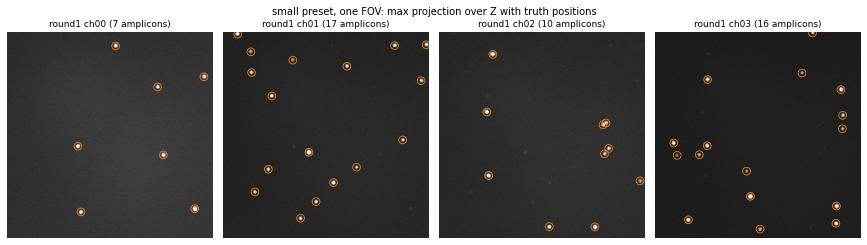

In [9]:
reference_round = scene.round_labels[0]
projection = scene.rounds[reference_round].max(axis=0)
channel_of = [codebook.color_to_channel[codeword[0]] for codeword in scene.formed.codeword]

fig, axes = plt.subplots(1, 4, figsize=(12, 3.3), dpi=72, constrained_layout=True)
for c, axis in enumerate(axes):
    axis.imshow(projection[..., c], cmap="gray", vmin=0, vmax=np.percentile(projection[..., c], 99.9))
    here = scene.formed[np.asarray(channel_of) == c]
    axis.scatter(here.x, here.y, s=60, facecolors="none", edgecolors="tab:orange", linewidths=0.8)
    axis.set_title(f"{reference_round} {scene.channel_labels[c]} ({len(here)} amplicons)", fontsize=9)
    axis.set_axis_off()
fig.suptitle("small preset, one FOV: max projection over Z with truth positions", fontsize=10)
plt.show()

## 3. One field of view through the maintained pipeline API

The pipeline is coordinated by three kinds of object:

* `Dataset` holds sample-level state: the input and output roots, the ordered
  sequencing rounds and reference round (`RoundState`), the channel order and the
  codebook.
* `FOV` holds per-FOV state: images, metadata and the typed result of each stage.
  Its methods call the same public functions a direct caller would use.
* `PipelineConfig` lists the scientific stages as typed configurations, and `None`
  disables a stage. `ExecutionConfig` separately chooses batch or streaming
  residency, and `CheckpointConfig` opts in to checkpoints and a run record.

`FOV.run` checks the configuration before it processes anything, then runs the
reference round first and the moving rounds in declared order. Loading is also a
stage: here the generator already produced ZYXC arrays with their metadata, so
they are placed on the FOV directly and `load` stays `None`. A real run sets
`load=ImageLoadConfig(...)` and reads TIFFs instead.

The settings are those of the documented quickstart, applied to this larger scene:
translation registration by phase correlation on the channel sum; noise-based
local maxima (median + 5 × MAD × 1.4826 per channel, minimum distance 1 voxel);
neighborhood-sum extraction over 3×5×5 voxels; winner-take-all decoding; and a
filter that keeps `assigned` calls. They are example settings, not tuned values.

In [10]:
from starfinder.barcode import NeighborhoodSumConfig, ReadFilterConfig, WtaDecoderConfig
from starfinder.dataset import Dataset, PipelineConfig, RegistrationStep, RoundState
from starfinder.registration import TranslationConfig

dataset = Dataset(
    input_root=WORKSPACE / "input", output_root=WORKSPACE / "results",
    dataset_id="tour", sample_id="synthetic", output_id="tour",
    rounds=RoundState(sequencing_rounds=list(codebook.round_labels), reference_round=reference_round),
    channel_order=codebook.channel_labels, codebook=codebook, fov_pattern="FOV_%03d",
)
fov = dataset.fov(scene_config.FOV_id)
for label in codebook.round_labels:
    fov.images[label] = scene.rounds[label]
    fov.metadata[label] = scene.round_metadata[label]

pipeline = PipelineConfig(
    registration=(RegistrationStep(TranslationConfig()),),
    detection=LocalMaximaConfig(threshold_mode="noise", threshold_value=5.0, min_distance_voxels=1),
    extraction=NeighborhoodSumConfig((1, 2, 2)),
    decoding=WtaDecoderConfig(),
    filtering=ReadFilterConfig(call_statuses=("assigned",)),
)
fov.run(pipeline, checkpoints=CheckpointConfig())
print("run finished for", fov.fov_id)

run finished for FOV_001


Each stage leaves a typed result on the FOV. Registration keeps an ordered list of
`RegistrationResult` objects per moving round; the stored *correction* is the
negative of the detected displacement. Spot finding returns a table with stable
spot identities. Extraction returns an N×C×R intensity array with labeled axes.
Decoding keeps one row per spot with its call status, and filtering annotates
every row and exposes the accepted view.

In [11]:
detected_shifts = {label: [-v for v in results[0].transform.correction_zyx]
                   for label, results in fov.registration_results.items()}
print("detected displacement (dz, dy, dx):", detected_shifts)
print("spots:", len(fov.spot_result.spots), " intensity array:", fov.intensity_result.values.shape,
      fov.intensity_result.round_labels)
print("call status:", fov.decoding_result.table.call_status.value_counts().sort_index().to_dict())
print("filtering:", fov.filtering_result.counts)
fov.filtering_result.accepted[["spot_id", "observed_color_sequence", "gene_id", "call_status", "wta_l2_nll"]].head().round(4)

detected displacement (dz, dy, dx): {'round2': [1.0, 3.0, 2.0], 'round3': [-1.0, -1.0, 3.0], 'round4': [1.0, 2.0, 5.0]}
spots: 68  intensity array: (68, 4, 4) ('round1', 'round2', 'round3', 'round4')
call status: {'assigned': 66, 'no_signal': 1, 'unmatched': 1}
filtering: {'total': 68, 'accepted': 66, 'rejected': 2}


,spot_id,observed_color_sequence,gene_id,call_status,wta_l2_nll
0,0,1212,GeneJ,assigned,0.2216
1,1,1331,GeneL,assigned,0.2086
2,2,1212,GeneJ,assigned,0.2739
3,3,1212,GeneJ,assigned,0.3807
4,4,1212,GeneJ,assigned,0.3875


## 4. Checkpoints and the run record

Checkpoints are **opt-in development aids**: with `checkpoints=None`, the default,
`run` writes nothing. With a `CheckpointConfig`, `run` writes up to three per-FOV
stages in existing formats (TIFF, CSV or Parquet, and JSON headers):

* `registered/`: each round as it enters detection, with the registration results
  in `transforms.json`;
* `candidates`: one wide row per spot with coordinates, detector columns and
  `sig_<round>_<channel>` / `valid_<round>` intensity columns;
* `pre_qc`: the decoding table unchanged, with the decoder configuration.

Each stage is written only when `run` computes it, and a stage can be reloaded into
a fresh FOV to rerun later stages without images, for example decoding and
filtering from `candidates`. Tables round-trip exactly: floats are written with 17
significant digits and read back through an explicit dtype map.

`run.json` is the **run record**. It is replaced atomically at the start, after
every completed step and at the end. It records identity, status and times, any
error, the code version and checkout state, the software environment, the full
configuration, hashed inputs, steps, registration attempts, result counts and the
checkpoint files. The layout and every field are described in
[docs/checkpoints.md](../../docs/checkpoints.md).

In [12]:
checkpoint_dir = fov.paths.checkpoint_dir
for path in sorted(checkpoint_dir.rglob("*")):
    if path.is_file():
        print(rel(path))

results/checkpoints/FOV_001/candidates.csv
results/checkpoints/FOV_001/candidates.json
results/checkpoints/FOV_001/pre_qc.csv
results/checkpoints/FOV_001/pre_qc.json
results/checkpoints/FOV_001/registered/round1.tif
results/checkpoints/FOV_001/registered/round2.tif
results/checkpoints/FOV_001/registered/round3.tif
results/checkpoints/FOV_001/registered/round4.tif
results/checkpoints/FOV_001/registered/transforms.json
results/checkpoints/FOV_001/run.json


In [13]:
record = json.loads((checkpoint_dir / "run.json").read_text())
print("fields:", list(record))
print("format_version:", record["format_version"], " status:", record["status"], " error:", record["error"])
print("identity:", {key: record[key] for key in ("dataset_id", "sample_id", "fov_id", "subtile_id")})
print("code fields:", sorted(record["code"]), " environment fields:", sorted(record["environment"]))
print("config sections:", sorted(record["config"]), " pipeline stages set:",
      sorted(k for k, v in record["config"]["pipeline"].items() if v not in (None, [], False, 0)))
print("inputs:", len(record["inputs"]), "(images were handed over in memory, so no TIFF was loaded or hashed)")
print("steps:", len(record["steps"]), "first:", [(s["name"], s["round"], s["status"]) for s in record["steps"][:4]])
print("counts:", record["counts"])
print("checkpoint_directory:", rel(record["checkpoint_directory"]))
print("checkpoints:", record["checkpoints"])

fields: ['format_version', 'dataset_id', 'sample_id', 'fov_id', 'subtile_id', 'status', 'started_at', 'ended_at', 'error', 'code', 'environment', 'config', 'inputs', 'steps', 'registration', 'counts', 'checkpoint_directory', 'checkpoints']
format_version: 1  status: succeeded  error: None
identity: {'dataset_id': 'tour', 'sample_id': 'synthetic', 'fov_id': 'FOV_001', 'subtile_id': None}
code fields: ['git_commit', 'git_dirty', 'version']  environment fields: ['packages', 'platform', 'python']
config sections: ['checkpoints', 'execution', 'pipeline']  pipeline stages set: ['decoding', 'detection', 'extraction', 'filtering', 'registration']
inputs: 0 (images were handed over in memory, so no TIFF was loaded or hashed)
steps: 17 first: [('write_checkpoint:registered', 'round1', 'succeeded'), ('find_spots', None, 'succeeded'), ('extract_round', 'round1', 'succeeded'), ('register', 'round2', 'succeeded')]
counts: {'spots': 68, 'intensities': 68, 'call_status': {'assigned': 66, 'no_signal': 

**Reload and decode again.** A fresh FOV from the same dataset restores the
`candidates` stage: spot table and intensities, with no images. `load_checkpoint`
first checks that the saved FOV id, round labels and channel order match this FOV.
Running a pipeline that contains only decoding and filtering then skips the round
loop. The assertions check that the result equals the in-memory run exactly.

In [14]:
reloaded = dataset.fov(scene_config.FOV_id).load_checkpoint("candidates")
assert not reloaded.images
reloaded.run(PipelineConfig(decoding=pipeline.decoding, filtering=pipeline.filtering))

pd.testing.assert_frame_equal(reloaded.spot_result.spots, fov.spot_result.spots)
np.testing.assert_array_equal(reloaded.intensity_result.values, fov.intensity_result.values)
np.testing.assert_array_equal(reloaded.intensity_result.valid, fov.intensity_result.valid)
pd.testing.assert_frame_equal(reloaded.decoding_result.table, fov.decoding_result.table)
pd.testing.assert_frame_equal(reloaded.filtering_result.table, fov.filtering_result.table)
assert reloaded.filtering_result.counts == fov.filtering_result.counts
print(f"decoding the reloaded candidates equals the in-memory result: "
      f"{len(reloaded.decoding_result.table)} decoded rows, "
      f"{len(reloaded.filtering_result.accepted)} accepted reads")

decoding the reloaded candidates equals the in-memory result: 68 decoded rows, 66 accepted reads


## 5. Decoded molecules against the synthetic truth

The `evaluation` subpackage holds **pure metrics**: it takes supplied points,
tables and metadata, and never runs detection or reads files. Every policy is the
caller's explicit choice and is recorded in the result: matching policy, distance
threshold and boundary, units, and which truth items are eligible. Undefined
values are `None`, never zero.

The choices here: truth positions are the formed reference positions, which are
in round 1's frame because round 1 is held at identity; eligible truth is the
amplicons whose centre lies inside the grid in round 1. Matching is greedy one-to-one
with an exclusive 5-voxel threshold, the historical spot-truth setting. Detection
is compared over all candidates and decoding over the accepted reads.

**This is an illustration on one small scene, not a benchmark.** The numbers
depend on this scene's draws and the example settings, carry no uncertainty
estimate, and support no claim about accuracy on other data.

In [15]:
from starfinder.evaluation.barcode import evaluate_decoding
from starfinder.evaluation.registration import evaluate_translation
from starfinder.evaluation.spot_finding import evaluate_spots

frame = scene.round_metadata[reference_round]
assert fov.metadata[reference_round] == frame
geometry = dict(reference_metadata=frame, observed_metadata=frame, units="voxel")

translation = evaluate_translation(detected_shifts, true_shifts, tolerance=None,
                                   eligible_rounds=list(dataset.rounds.moving_rounds), **geometry)
print("registration: max per-axis error", round(translation.values["max_error"], 3), "voxel,",
      "mean L2 error", round(translation.values["mean_error_l2"], 3), "voxel")

registration: max per-axis error 0.742 voxel, mean L2 error 0.612 voxel


In [16]:
in_frame = scene.round_truth.query("round_label == @reference_round").set_index("amplicon_id")
truth = scene.formed.assign(gene=scene.formed.gene_id, color_seq=scene.formed.codeword)
eligible = in_frame.loc[truth.amplicon_id, "center_in_bounds"].to_numpy(dtype=bool)
matching = dict(policy="greedy", threshold=5.0, boundary="exclusive", eligible_reference=eligible, **geometry)


def decoded_view(reads):
    # Join coordinates to reads on spot_id; row order follows the reads.
    table = reads.merge(fov.spot_result.spots[["spot_id", "z", "y", "x"]], on="spot_id", validate="one_to_one")
    return table.rename(columns={"gene_id": "gene", "observed_color_sequence": "color_seq"})


candidates = decoded_view(fov.decoding_result.table)
accepted = decoded_view(fov.filtering_result.accepted)
spots = evaluate_spots(candidates[["z", "y", "x"]].to_numpy(), truth[["z", "y", "x"]].to_numpy(), **matching)
reads = evaluate_decoding(accepted, truth, matches=evaluate_spots(
    accepted[["z", "y", "x"]].to_numpy(), truth[["z", "y", "x"]].to_numpy(), **matching))

print("detection, all candidates:", spots.status)
print(f"  eligible truth {spots.counts['eligible_reference']}, candidates {spots.counts['eligible_observed']}, "
      f"matched {spots.counts['matched']}")
print(f"  recall {spots.values['recall']:.3f}, precision {spots.values['precision']:.3f}, "
      f"mean distance {spots.values['mean_distance']:.3f} voxel")
print("decoding, accepted reads:", reads.status)
print(f"  matched {reads.counts['matched']} of {reads.counts['total_observed']} accepted reads; "
      f"correct gene {reads.counts['correct_gene']}/{reads.counts['eligible_gene']}, "
      f"correct color sequence {reads.counts['correct_color_seq']}/{reads.counts['eligible_color_seq']}")
print("  gene confusion:", reads.details["gene_confusion"] or "none")

detection, all candidates: ok
  eligible truth 50, candidates 68, matched 45
  recall 0.900, precision 0.662, mean distance 0.532 voxel
decoding, accepted reads: ok
  matched 44 of 66 accepted reads; correct gene 44/44, correct color sequence 44/44
  gene confusion: none


Reading the output: `recall` is the fraction of eligible truth amplicons with a
one-to-one match within the threshold, and `precision` the fraction of candidates
with one. Gene and color-sequence accuracy are conditional on a spatial match, so
unmatched truth lowers recall but not decoding accuracy. Candidates without a
matching amplicon lower precision; this notebook does not investigate their origin.

## 6. How development is checked

Development is checked in layers. Each checks software behavior on synthetic or
small inputs; none of them validates biological accuracy on real data.

* **Default pytest tier.** From `src/python`, `uv run pytest test/ -v`. The
  project's pytest configuration excludes tests marked `extended`, so the default
  run covers unit, contract, synthetic-oracle and checkpoint tests on small arrays.
  Resource and unraisable-exception warnings are errors.
* **Extended tier.** `uv run pytest test/ -v -m extended` runs the full-pipeline
  end-to-end comparisons on a session-generated `small` synthetic dataset. Run it
  when changing the pipeline.
* **Strict documentation build.** `uv run --group docs sphinx-build -n -W
  --keep-going -b html ../../docs <output>` treats every warning, including a broken
  cross-reference, as an error. `uv run python ../../docs/check_reference.py` audits
  export parity, reference ordering and the site navigation.
* **Continuous integration.** The `Tests` workflow installs the locked environment
  and runs the default and extended tiers on pushes and pull requests to `dev` and
  `main`. The `Documentation` workflow runs the strict build and the bounded
  quickstart and recipe examples, and publishes only from its release branch. See
  [docs/contributing.md](../../docs/contributing.md).
* **The MATLAB launcher.** MATLAB rules in the Snakemake workflow start MATLAB
  through a small configuration-driven launcher. `matlab_launcher: path` (the
  default) uses `STARFINDER_MATLAB_EXECUTABLE` or `matlab` on `PATH`;
  `matlab_launcher: broad` uses the Broad `use Matlab` environment; and
  `matlab_single_thread: true` adds `-singleCompThread`. It runs the entry point with
  `-batch`, so a MATLAB error fails the job, and it rejects bad settings before
  MATLAB starts. Its tests mock `subprocess`, so neither CI nor this notebook
  executes MATLAB. See
  [docs/workflow-configuration.md](../../docs/workflow-configuration.md#matlab-launcher).

The cell below reads these settings from the repository files rather than
restating them. It only reads files; it runs no tests, builds and no MATLAB.

In [17]:
import tomllib

import starfinder
import yaml

python_root = Path(starfinder.__file__).resolve().parents[1]
repository = python_root.parents[1]
pytest_options = tomllib.loads((python_root / "pyproject.toml").read_text())["tool"]["pytest"]["ini_options"]
print("pytest addopts:  ", pytest_options["addopts"])
print("pytest markers:  ", pytest_options["markers"])
print("warnings as errors:", pytest_options["filterwarnings"])

for name in ("tests.yml", "docs.yml"):
    workflow = yaml.safe_load((repository / ".github" / "workflows" / name).read_text())
    for job_name, job in workflow["jobs"].items():
        steps = [step["name"] for step in job["steps"] if "name" in step]
        print(f"\n{workflow['name']} / {job_name}:")
        for step in steps:
            print("  -", step)

example = yaml.safe_load((repository / "docs" / "examples" / "workflow-full.yaml").read_text())
print("\nlauncher keys in the full workflow example:",
      {key: example[key] for key in ("backend", "matlab_launcher", "matlab_single_thread")})

pytest addopts:   -v --tb=short -m 'not extended'
pytest markers:   ["extended: full-pipeline end-to-end comparisons on the session's synthetic data; run with -m extended"]
warnings as errors: ['error::ResourceWarning', 'error::pytest.PytestUnraisableExceptionWarning']

Tests / pytest:
  - Install locked dependencies with the dev, local-registration and checkpoint extras
  - Default suite
  - Extended suite

Documentation / docs:
  - Set external output paths
  - Install locked runtime and docs dependencies
  - Strict HTML and internal references
  - Fixed-input quickstart and recipes
  - External links (manual opt-in)
  - Record publication revision
  - Upload Pages site
  - Record validation scope
  - Retain validation evidence

Documentation / deploy:
  - Check Pages configuration
  - Deploy checked documentation

launcher keys in the full workflow example: {'backend': 'python', 'matlab_launcher': 'path', 'matlab_single_thread': False}


## Clean up

The notebook wrote only inside its temporary workspace. The last cell reports what
it wrote and removes the workspace.

In [18]:
written = [path for path in WORKSPACE.rglob("*") if path.is_file()]
print(f"{len(written)} files, {sum(p.stat().st_size for p in written) / 2**20:.1f} MiB written, all under",
      sorted({rel(p).split('/')[0] for p in written}))
_workspace.cleanup()
print("workspace removed:", not WORKSPACE.exists())

10 files, 34.6 MiB written, all under ['results']
workspace removed: True
